# 개요

- $H\delta = -g$ 를 **어떻게 푸느냐**가 정확도를 결정한다. 비선형 최적화의 반복 한 번은 결국 선형 최소제곱 한 번이다.
- Normal equation을 만드는 순간 조건수가 제곱된다는 사실과, 그 대가로 무엇을 얻는지를 숫자로 확인한다.

# 1. 최소제곱과 조건수

- `Normal equation` $J^{T}J\delta = -J^{T}r$
	- $H$ 를 만들어 Cholesky. 가장 싸고, SLAM이 실제로 쓰는 방식
- `QR` $J = QR$
	- $H$ 를 만들지 않는다. 느리지만 조건수에 강하다

---
## 1.1. 최소제곱의 해

$\min_{\delta}\|J\delta + r\|^{2}$ 를 $\delta$ 로 미분해 0으로 두면 정규방정식을 얻는다.

$$
\boxed{
J^{T}J\,\delta = -J^{T}r
}
$$

- $J$: $(m, n)$, $m > n$
- $r$: $(m,)$ 잔차

---
## 1.2. 조건수가 제곱된다

$J = U\Sigma V^{T}$ 로 두면 $J^{T}J = V\Sigma^{2}V^{T}$ 이므로, 특이값이 그대로 제곱된다.

$$
\boxed{
\kappa(J^{T}J) = \frac{\sigma_{\max}^{2}}{\sigma_{\min}^{2}} = \kappa(J)^{2}
}
$$

즉,

> $J$ 를 $J^{T}J$ 로 바꾸는 순간 유효자릿수의 절반을 버린다

배정밀도의 상대오차 한계가 $\epsilon \approx 10^{-16}$ 이므로, 해의 상대오차는 대략 $\kappa \cdot \epsilon$ 이다.
정규방정식은 $\kappa(J)^{2}\epsilon$ 이 되어 $\kappa(J) \approx 10^{8}$ 에서 자릿수를 전부 잃는다.

---
## 1.3. $H$ 를 만들지 않는 풀이

$J = QR$ ($Q$ 는 열직교, $R$ 은 상삼각)로 두면 $Q$ 가 노름을 보존하므로:

$$ \|J\delta + r\|^{2} = \|Q^{T}(J\delta + r)\|^{2} = \|R\delta + Q^{T}r\|^{2} $$

$$
\boxed{
R\,\delta = -Q^{T}r
}
$$

$R$ 은 상삼각이라 후진대입으로 바로 풀린다. $\kappa(R) = \kappa(J)$ 이므로 제곱이 일어나지 않는다.

---
## 1.4. 전체 파이프라인

$$ \boxed{ J, r \rightarrow \{\,J^{T}J\delta = -J^{T}r \;\;|\;\; R\delta = -Q^{T}r\,\} \rightarrow \delta \rightarrow \|\delta - \delta^{*}\| } $$

```txt
            J (m x n)
             |
    +--------+---------+
    |                  |
 J^T J (n x n)      QR 분해
 kappa 제곱         kappa 유지
    |                  |
 Cholesky           후진대입
    |                  |
    +--------+---------+
             |
        같은 답? -> kappa 를 키우며 확인
```

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# numpy 2.x + Apple Accelerate 조합에서 matmul 이 부동소수점 상태 플래그를 잘못 남긴다.
# 결과값은 전부 정상이라(직접 대조해 확인했다) 이 조합에서만 나오는 잡음만 끈다.
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)


def pick_korean_font():
    """한글과 수학 마이너스(U+2212)를 **둘 다** 가진 폰트를 우선 고른다.

    로그 축 눈금은 $\mathdefault{10^{-13}}$ 로 그려지는데, mathtext 는 여기서 font.family 를
    쓴다. AppleGothic 계열에는 U+2212 가 없어서 지수의 마이너스가 네모로 깨진다 —
    한글은 멀쩡해서 알아채기 어렵다.
    """
    available = {f.name for f in font_manager.fontManager.ttflist}
    candidates = ("Arial Unicode MS", "Noto Sans CJK KR", "NanumGothic",
                  "Malgun Gothic", "Apple SD Gothic Neo", "AppleGothic")
    fallback = None
    for name in candidates:
        if name not in available:
            continue
        fallback = fallback or name
        try:
            path = font_manager.findfont(font_manager.FontProperties(family=name),
                                         fallback_to_default=False)
            if font_manager.get_font(path).get_char_index(0x2212):
                return name, True
        except Exception:
            continue
    return fallback, False


_font, _has_minus = pick_korean_font()
if _font:
    plt.rcParams["font.family"] = _font
    plt.rcParams["axes.unicode_minus"] = _has_minus   # 없으면 ASCII 하이픈으로 대체
    plt.rcParams["mathtext.fontset"] = "dejavusans"
print(f"font: {_font}  (U+2212 보유: {_has_minus})")

font: Arial Unicode MS  (U+2212 보유: True)


## 0. 샘플 데이터 생성하기

- `make_conditioned_lsq` 는 SVD로 거꾸로 만들어 **조건수를 설계값 그대로** 맞춘다.
- 참값 `x_true` 를 알고 있으므로 "풀렸다"가 아니라 "맞게 풀렸다"를 잴 수 있다.

In [2]:
import importlib
import problems
importlib.reload(problems)                 # 커널을 재시작하지 않아도 최신 버전을 반영
from problems import *

J, b, x_true = make_conditioned_lsq(m=60, n=8, cond=1e6, seed=0)

print("J        :", J.shape)
print("kappa(J) : %.3e  (설계값 1e+06)" % np.linalg.cond(J))
print("kappa(H) : %.3e  <- 제곱됐다" % np.linalg.cond(J.T @ J))
print("x_true   :", x_true)

J        : (60, 8)
kappa(J) : 1.000e+06  (설계값 1e+06)
kappa(H) : 1.000e+12  <- 제곱됐다
x_true   : [ 0.806  -1.2259 -0.0225  0.1242  0.8622  0.1161  0.8041 -0.5042]


# 1. 데이터 시각화

특이값이 어떻게 깔려 있는지부터 본다. 조건수는 결국 이 그림의 세로 폭이다.

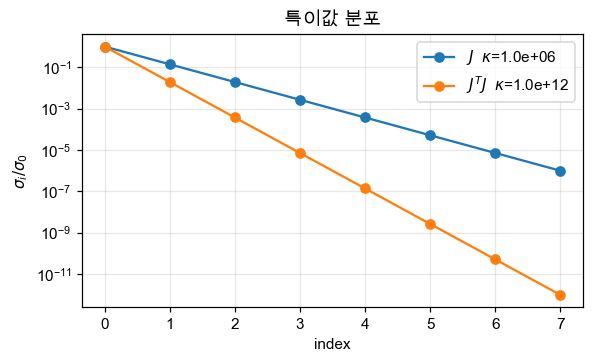

In [3]:
def show_spectrum(mats, labels):
    """특이값을 로그 축으로. 조건수 = 맨 위 / 맨 아래."""
    plt.figure(figsize=(5.5, 3.4))
    for M, label in zip(mats, labels):
        s = np.linalg.svd(M, compute_uv=False)
        plt.semilogy(s / s[0], "o-", label=f"{label}  $\\kappa$={s[0]/s[-1]:.1e}")
    plt.xlabel("index"); plt.ylabel("$\\sigma_i / \\sigma_0$")
    plt.title("특이값 분포"); plt.grid(True, which="both", alpha=0.3); plt.legend()
    plt.tight_layout(); plt.show()


show_spectrum([J, J.T @ J], ["$J$", "$J^TJ$"])

# 2. 세 가지 풀이

박스 수식 하나에 셀 하나씩.

In [4]:
# 1. 정규방정식 - J^T J delta = -J^T r
def solve_normal(J, b):
    """H 를 만들어 푼다. SLAM 이 쓰는 방식이고, 희소행렬에서는 압도적으로 싸다."""
    H = J.T @ J                                  # (n, n)
    g = J.T @ b                                  # (n,)
    return np.linalg.solve(H, g)                 # 역행렬을 만들지 않는다

In [5]:
# 2. QR - R delta = -Q^T r
def solve_qr(J, b):
    """H 를 만들지 않는다. Q 가 노름을 보존하므로 최소제곱 해가 그대로 보존된다."""
    Q, R = np.linalg.qr(J)                       # (m, n), (n, n)
    return np.linalg.solve(R, Q.T @ b)           # R 은 상삼각 -> 후진대입

In [6]:
# 3. SVD - rank 결핍까지 보여주는 가장 비싼 풀이
def solve_svd(J, b, rcond=None):
    """작은 특이값을 잘라내 rank 결핍을 흡수한다. pinv 가 하는 일이다."""
    return np.linalg.lstsq(J, b, rcond=rcond)[0]

## 2.1. 조건수를 키우며 무너지는 지점 찾기

메인 루프. 세 풀이를 같은 문제에 걸고 참값과의 상대오차를 잰다.

In [7]:
conds = np.logspace(2, 14, 13)
solvers = {"normal equation": solve_normal, "QR": solve_qr, "SVD (lstsq)": solve_svd}
errors = {name: [] for name in solvers}

for cond in conds:
    # 1. 조건수가 cond 인 문제 생성 - 참값을 함께 받는다
    J_k, b_k, x_k = make_conditioned_lsq(m=60, n=8, cond=cond, seed=0)
    for name, solve in solvers.items():
        # 2~4. 각 방식으로 풀고
        x_hat = solve(J_k, b_k)
        # 5. 참값 대비 상대오차
        errors[name].append(np.linalg.norm(x_hat - x_k) / np.linalg.norm(x_k))

for name in solvers:
    print(f"{name:16s}", " ".join(f"{e:8.1e}" for e in errors[name]))

normal equation   8.0e-14  7.4e-11  5.3e-09  5.5e-07  7.1e-05  3.9e-04  4.3e-01  1.4e+01  4.1e+00  2.3e+00  3.3e+00  2.2e+00  3.2e+00
QR                2.1e-15  8.7e-15  7.2e-14  9.2e-13  8.7e-12  1.6e-11  5.5e-10  9.9e-09  5.9e-09  7.2e-07  1.3e-06  3.7e-05  1.4e-03
SVD (lstsq)       2.7e-15  4.2e-15  1.2e-14  6.4e-13  7.5e-12  2.3e-11  3.6e-10  1.3e-08  1.4e-08  6.0e-07  3.7e-06  3.5e-05  2.2e-01


# 3. 검증

돌아간다는 것과 맞다는 것은 다르다. 참값이 있으니 숫자로 채점한다.

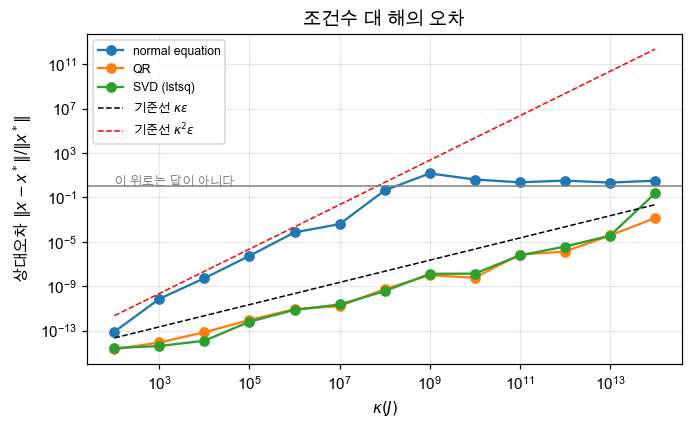

In [8]:
plt.figure(figsize=(6.4, 4.0))
for name, err in errors.items():
    plt.loglog(conds, np.maximum(err, 1e-18), "o-", label=name)

eps = np.finfo(float).eps
plt.loglog(conds, conds * eps, "k--", lw=1, label=r"기준선 $\kappa\epsilon$")
plt.loglog(conds, conds ** 2 * eps, "r--", lw=1, label=r"기준선 $\kappa^2\epsilon$")
plt.axhline(1.0, color="gray", lw=1)
plt.text(conds[0], 1.3, "이 위로는 답이 아니다", fontsize=8, color="gray")

plt.xlabel(r"$\kappa(J)$"); plt.ylabel("상대오차 $\\|x - x^*\\| / \\|x^*\\|$")
plt.title("조건수 대 해의 오차"); plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

In [9]:
# 기울기로 kappa^2 를 확인한다 - 로그-로그에서 기울기가 곧 지수다
def log_slope(x, y, lo, hi):
    """유효한 구간(오차가 아직 1 미만)에서만 기울기를 잰다."""
    x, y = np.asarray(x), np.asarray(y)
    m = (x >= lo) & (x <= hi) & (y > 0) & (y < 1.0)
    return np.polyfit(np.log10(x[m]), np.log10(y[m]), 1)[0]


for name in solvers:
    print(f"{name:16s} 기울기 = {log_slope(conds, errors[name], 1e2, 1e12):.2f}")
print("\n정규방정식이 2, QR/SVD 가 1 에 가까우면 kappa^2 대 kappa 가 확인된 것이다.")

normal equation  기울기 = 1.99
QR               기울기 = 0.91
SVD (lstsq)      기울기 = 0.97

정규방정식이 2, QR/SVD 가 1 에 가까우면 kappa^2 대 kappa 가 확인된 것이다.


## 3.1. 그러면 왜 SLAM은 정규방정식을 쓰는가

정확도만 보면 QR이 이긴다. 그런데 BA의 $J$ 는 $(수십만, 수만)$ 크기에 99% 이상이 0이다.

- $J^{T}J$ 는 **희소성을 유지**한다. pose 쌍이 같은 landmark를 볼 때만 채워진다
- QR의 $Q$ 는 **dense**가 된다. 메모리부터 감당이 안 된다

그리고 SLAM의 $\kappa(J)$ 는 보통 $10^{3}\!\sim\!10^{5}$ 라 제곱해도 $10^{10}$, 아직 배정밀도 안이다.
**조건수가 감당 범위일 때만 유효한 거래**이고, 그 경계가 어디인지가 위 그림이다.

## 3.2. 한계

- 여기서는 $J$ 를 dense로 만들었다. 희소행렬에서의 실제 비용 차이는 `05` 노트북에서 다룬다
- `lstsq` 의 `rcond` 를 건드리면 SVD 곡선이 달라진다. 기본값은 rank 절단을 거의 하지 않는다